# CNN Key Prediction
Trains a 2-D convolutional neural network on CQT chromagrams to predict the musical key (24 classes: 12 major + 12 minor) of each 30-second GTZAN clip.

In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import warnings
warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cpu


In [ ]:
# --- Configuration ---
CSV_PATH    = '../gtzan/GTZAN_Enriched_V2.csv'
AUDIO_ROOT  = '../gtzan/Data/genres_original'
CACHE_DIR   = 'chromagram_cache'

SR          = 22050
HOP_LENGTH  = 512
DURATION    = 30       # seconds
N_CHROMA    = 12
# Fixed time dimension: ceil(30 * 22050 / 512)
T_FIXED     = int(np.ceil(DURATION * SR / HOP_LENGTH))
print(f'Chromagram shape per clip: ({N_CHROMA}, {T_FIXED})')

# Training
TEST_SIZE   = 0.2
BATCH_SIZE  = 32
EPOCHS      = 40
LR          = 1e-3
NUM_CLASSES = 24   # 0-11 major, 12-23 minor

PITCH_NAMES = ['A', 'A#', 'B', 'C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#']
KEY_NAMES   = PITCH_NAMES + [p + 'm' for p in PITCH_NAMES]

## 1. Feature Extraction
Computes CQT chromagrams for each clip and caches them as `.npy` files so re-runs are fast.

In [3]:
os.makedirs(CACHE_DIR, exist_ok=True)

df = pd.read_csv(CSV_PATH)
# Drop rows with unknown/modulation key
df = df[df['GT Key'].notna() & (df['GT Key'].astype(int) != -1)].reset_index(drop=True)
df['GT Key'] = df['GT Key'].astype(int)
print(f'{len(df)} clips with valid GT keys')

def compute_chromagram(wav_path):
    y, sr = librosa.load(wav_path, sr=SR, mono=True, duration=DURATION)
    y_harmonic, _ = librosa.effects.hpss(y)
    chroma = librosa.feature.chroma_cqt(y=y_harmonic, sr=SR, hop_length=HOP_LENGTH)
    # Pad or truncate to T_FIXED
    if chroma.shape[1] < T_FIXED:
        chroma = np.pad(chroma, ((0, 0), (0, T_FIXED - chroma.shape[1])))
    else:
        chroma = chroma[:, :T_FIXED]
    return chroma.astype(np.float32)  # (12, T_FIXED)

chromagrams = []
labels      = []
skipped     = 0

for _, row in df.iterrows():
    genre    = row['Genre']
    filename = row['File Name']
    gt_key   = row['GT Key']

    cache_path = os.path.join(CACHE_DIR, f"{os.path.splitext(filename)[0]}.npy")

    if os.path.exists(cache_path):
        chroma = np.load(cache_path)
    else:
        wav_path = os.path.join(AUDIO_ROOT, genre, filename)
        if not os.path.exists(wav_path):
            skipped += 1
            continue
        chroma = compute_chromagram(wav_path)
        np.save(cache_path, chroma)

    chromagrams.append(chroma)
    labels.append(gt_key)

print(f'Loaded {len(chromagrams)} chromagrams  |  skipped {skipped} missing files')
print(f'Class distribution:\n{pd.Series(labels).value_counts().sort_index().rename(index=lambda i: KEY_NAMES[i])}')

838 clips with valid GT keys
Loaded 838 chromagrams  |  skipped 0 missing files
Class distribution:
A      35
A#     28
B      14
C      57
C#     21
D      34
D#     24
E      24
F      53
F#      9
G      45
G#     23
Am     77
A#m    30
Bm     46
Cm     51
C#m    20
Dm     41
D#m    35
Em     52
Fm     29
F#m    25
Gm     49
G#m    16
Name: count, dtype: int64


## 2. Dataset & DataLoaders

In [4]:
class ChromaDataset(Dataset):
    def __init__(self, chromas, labels):
        # shape: (N, 1, 12, T_FIXED) — add channel dim
        self.X = torch.tensor(np.stack(chromas)[:, np.newaxis], dtype=torch.float32)
        self.y = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


X_train, X_test, y_train, y_test = train_test_split(
    chromagrams, labels,
    test_size=TEST_SIZE,
    random_state=42,
    stratify=labels,
)

train_ds = ChromaDataset(X_train, y_train)
test_ds  = ChromaDataset(X_test,  y_test)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train: {len(train_ds)}  |  Test: {len(test_ds)}')

Train: 670  |  Test: 168


## 3. Model
A small 2-D CNN that treats the chromagram as a `(1, 12, T)` image. Two convolutional blocks extract local pitch-time patterns; global average pooling makes the FC head input-size-independent.

In [5]:
class KeyCNN(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1,  32, kernel_size=(3, 7), padding=(1, 3)),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(1, 4)),   # keep pitch dim, compress time
            nn.Dropout2d(0.25),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=(3, 5), padding=(1, 2)),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=(2, 4)),
            nn.Dropout2d(0.25),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=(3, 3), padding=(1, 1)),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),   # global average pool → (batch, 128, 1, 1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = KeyCNN().to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {total_params:,}')

KeyCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 7), stride=(1, 1), padding=(1, 3))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(1, 4), stride=(1, 4), padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(32, 64, kernel_size=(3, 5), stride=(1, 1), padding=(1, 2))
    (6): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 4), stride=(2, 4), padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (12): ReLU()
    (13): AdaptiveAvgPool2d(output_size=(1, 1))
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=

## 4. Training

In [6]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

train_losses, test_losses = [], []
train_accs,   test_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    # --- Train ---
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        out  = model(X_batch)
        loss = criterion(out, y_batch)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(y_batch)
        correct      += (out.argmax(1) == y_batch).sum().item()
        total        += len(y_batch)
    scheduler.step()
    train_losses.append(running_loss / total)
    train_accs.append(correct / total)

    # --- Evaluate ---
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            out  = model(X_batch)
            loss = criterion(out, y_batch)
            running_loss += loss.item() * len(y_batch)
            correct      += (out.argmax(1) == y_batch).sum().item()
            total        += len(y_batch)
    test_losses.append(running_loss / total)
    test_accs.append(correct / total)

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:>3}/{EPOCHS}  '
              f'train loss {train_losses[-1]:.4f}  acc {train_accs[-1]:.3f}  |  '
              f'test  loss {test_losses[-1]:.4f}  acc {test_accs[-1]:.3f}')

Epoch   1/40  train loss 3.1745  acc 0.042  |  test  loss 3.1385  acc 0.060
Epoch   5/40  train loss 3.0153  acc 0.109  |  test  loss 2.9959  acc 0.119
Epoch  10/40  train loss 2.9800  acc 0.139  |  test  loss 2.9201  acc 0.143
Epoch  15/40  train loss 2.8289  acc 0.161  |  test  loss 2.7806  acc 0.185
Epoch  20/40  train loss 2.7579  acc 0.193  |  test  loss 2.6495  acc 0.256
Epoch  25/40  train loss 2.6553  acc 0.203  |  test  loss 2.5104  acc 0.304
Epoch  30/40  train loss 2.5633  acc 0.227  |  test  loss 2.4407  acc 0.292
Epoch  35/40  train loss 2.5618  acc 0.213  |  test  loss 2.4086  acc 0.310
Epoch  40/40  train loss 2.5206  acc 0.222  |  test  loss 2.4053  acc 0.321


## 5. Evaluation

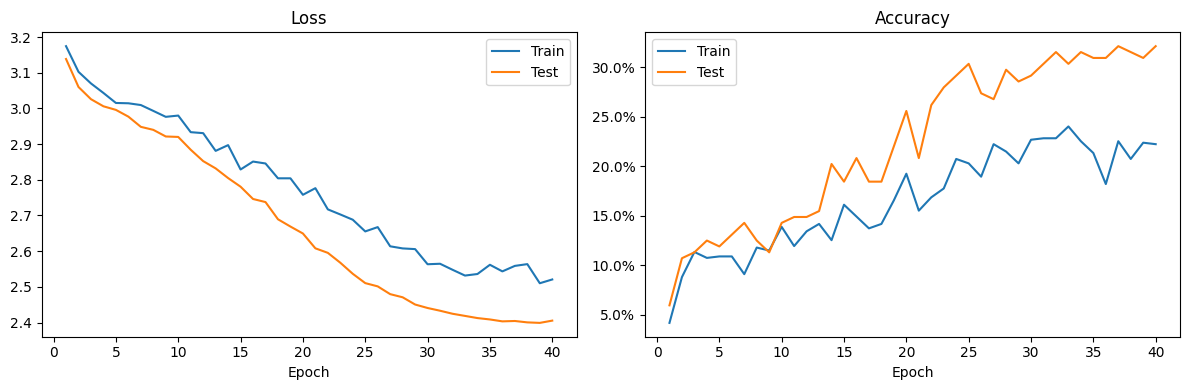

Final test accuracy: 32.1%


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, EPOCHS + 1)

ax1.plot(epochs, train_losses, label='Train')
ax1.plot(epochs, test_losses,  label='Test')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs, train_accs, label='Train')
ax2.plot(epochs, test_accs,  label='Test')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))
ax2.legend()

plt.tight_layout()
plt.show()
print(f'Final test accuracy: {test_accs[-1]:.1%}')

In [8]:
model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = model(X_batch.to(DEVICE)).argmax(1).cpu()
        all_preds.extend(preds.tolist())
        all_true.extend(y_batch.tolist())

present_classes = sorted(set(all_true))
print(classification_report(
    all_true, all_preds,
    labels=present_classes,
    target_names=[KEY_NAMES[i] for i in present_classes],
))

              precision    recall  f1-score   support

           A       0.67      0.29      0.40         7
          A#       0.00      0.00      0.00         6
           B       0.00      0.00      0.00         3
           C       0.38      0.82      0.51        11
          C#       0.00      0.00      0.00         4
           D       1.00      0.14      0.25         7
          D#       0.17      0.20      0.18         5
           E       0.50      0.20      0.29         5
           F       0.33      0.45      0.38        11
          F#       0.00      0.00      0.00         2
           G       0.50      0.33      0.40         9
          G#       0.00      0.00      0.00         5
          Am       0.30      0.73      0.42        15
         A#m       0.00      0.00      0.00         6
          Bm       0.29      0.44      0.35         9
          Cm       0.30      0.70      0.42        10
         C#m       0.00      0.00      0.00         4
          Dm       0.00    

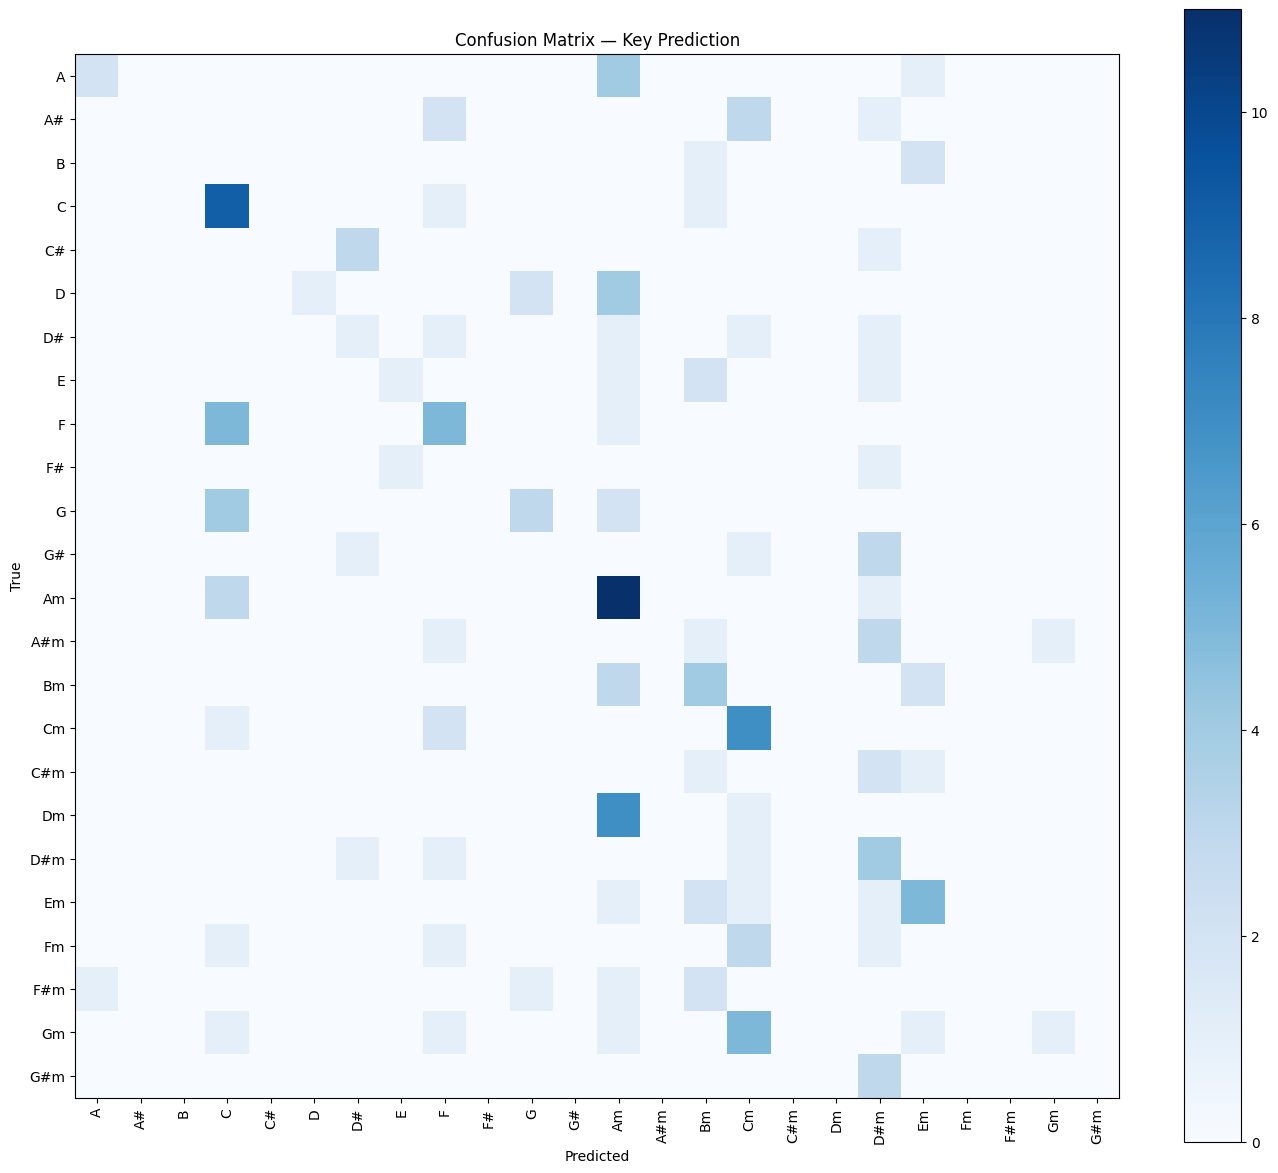

In [9]:
cm = confusion_matrix(all_true, all_preds, labels=present_classes)
tick_labels = [KEY_NAMES[i] for i in present_classes]

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(cm, cmap='Blues')
fig.colorbar(im, ax=ax)
ax.set_xticks(range(len(present_classes)), tick_labels, rotation=90)
ax.set_yticks(range(len(present_classes)), tick_labels)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('Confusion Matrix — Key Prediction')
plt.tight_layout()
plt.show()